In [1]:
%pip install google-generativeai datasets pandas tqdm scikit-learn python-dotenv

import google.generativeai as genai
from google.generativeai.types import HarmCategory, HarmBlockThreshold
from datasets import load_dataset
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import time
import os
import json
import uuid
import re
from tqdm import tqdm
from dotenv import load_dotenv

# Load API key from your .env file
load_dotenv()
API_KEY = os.getenv("API_KEY")

Note: you may need to restart the kernel to use updated packages.


/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/2p/xnjv139d2ng8q9pmjm0k0w9m0000gn/T/ipykernel_48210/1032341030.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
# 1. Load the dataset
goEmotionsDataset = load_dataset('go_emotions')
sentimentLabels = goEmotionsDataset['train'].features['labels'].feature.names

# 2. bucket mapping
sentimentMap = {
  "Positive": ["admiration", "amusement", "approval", "caring", "desire", "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
  "Negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust", "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
  "Neutral": ["neutral", "realization", "surprise", "curiosity", "confusion"]
}

def get_true_bucket(label_indices):
    pos_score = sum(1 for idx in label_indices if sentimentLabels[idx] in sentimentMap['Positive'])
    neg_score = sum(1 for idx in label_indices if sentimentLabels[idx] in sentimentMap['Negative'])
    neu_score = sum(1 for idx in label_indices if sentimentLabels[idx] in sentimentMap['Neutral'])
    
    scores = {'Positive': pos_score, 'Negative': neg_score, 'Neutral': neu_score}
    return max(scores, key=scores.get)

print("Dataset loaded and bucket mapping ready.")

Dataset loaded and bucket mapping ready.


In [3]:
def setup_model():
    genai.configure(api_key=API_KEY)
    
    generation_config = {
        "temperature": 0.0, 
        "top_p": 0.95,
        "max_output_tokens": 1024,
        "response_mime_type": "application/json",
    }
    
    # Disable safety blocks to prevent dropped political comments
    safety_settings = {
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
    }

    # FEW-SHOT PROMPT
    system_instruction = (
        "You are an expert sentiment classification system. Your task is to analyze Reddit comments "
        "and classify their emotional sentiment into exactly one of three buckets: 'Positive', 'Negative', or 'Neutral'.\n\n"
        "Here are some examples of how to classify:\n"
        "Comment: \"I absolutely love the new design! Great job to the devs.\"\n"
        "Sentiment: Positive\n\n"
        "Comment: \"This is the worst update ever, completely broken and unplayable.\"\n"
        "Sentiment: Negative\n\n"
        "Comment: \"The patch notes were released yesterday afternoon.\"\n"
        "Sentiment: Neutral\n\n"
        "Comment: \"I'm so frustrated with how long this is taking to resolve.\"\n"
        "Sentiment: Negative\n\n"
        "Comment: \"Wow, I am so incredibly happy for you! Congratulations!\"\n"
        "Sentiment: Positive\n\n"
        "Return a JSON object with a single key 'sentiment' containing either 'Positive', 'Negative', or 'Neutral'."
    )
    
    return genai.GenerativeModel(
        model_name='gemini-2.0-flash',
        generation_config=generation_config,
        safety_settings=safety_settings,
        system_instruction=system_instruction
    )

def analyze_comment(model, body):
    prompt = f"RequestID: {str(uuid.uuid4())}\nComment Body: {body}"
    
    for attempt in range(3):
        try:
            response = model.generate_content(prompt)
            if not response.parts:
                return "Neutral"
            
            text_content = response.text.strip()
            if "```" in text_content:
                text_content = re.sub(r'```json\s*|\s*```', '', text_content)
            
            result = json.loads(text_content)
            sentiment = result.get("sentiment", "Neutral").capitalize()
            
            return sentiment if sentiment in ["Positive", "Negative", "Neutral"] else "Neutral"

        except Exception as e:
            time.sleep(2) 
            
    return "Neutral"

model = setup_model()
print("Gemini initialized with few-shot prompt.")

Gemini initialized with few-shot prompt.


In [4]:
llm_predictions = []
true_buckets = []

NUM_SAMPLES = len(goEmotionsDataset['test']) 

print(f"Running Few-Shot Baseline on {NUM_SAMPLES} GoEmotions test samples...")
start_time = time.time()

for i in tqdm(range(NUM_SAMPLES)):
    # 1. Pull text and true labels
    comment_text = goEmotionsDataset['test'][i]['text']
    true_raw_labels = goEmotionsDataset['test'][i]['labels'] 
    
    # 2. Get predictions and ground truth
    prediction = analyze_comment(model, body=comment_text)
    ground_truth = get_true_bucket(true_raw_labels)
    
    llm_predictions.append(prediction)
    true_buckets.append(ground_truth)
    
    # Rate limit protection (Adjust if you have a higher tier API key)
    time.sleep(1.0) 

end_time = time.time()
print(f"Inference complete! Total time: {end_time - start_time:.2f} seconds.")

Running Few-Shot Baseline on 5427 GoEmotions test samples...


100%|██████████| 5427/5427 [3:35:38<00:00,  2.38s/it]     

Inference complete! Total time: 12938.01 seconds.


In [5]:
print("\nFew-Shot LLM Baseline Evaluation (3 Buckets):")
print("-" * 50)
print(classification_report(
    true_buckets,
    llm_predictions,
    labels=['Positive', 'Negative', 'Neutral'] 
))


Few-Shot LLM Baseline Evaluation (3 Buckets):
--------------------------------------------------
              precision    recall  f1-score   support

    Positive       0.83      0.54      0.65      2098
    Negative       0.52      0.69      0.59      1182
     Neutral       0.58      0.67      0.62      2147

    accuracy                           0.62      5427
   macro avg       0.64      0.63      0.62      5427
weighted avg       0.66      0.62      0.63      5427



Reconstructed confusion matrix (from precision/recall/support):
Rows = True label, Cols = Predicted
[[1133  240  732]
 [  40  816  323]
 [ 192  513 1438]]
Row sums: [2105 1179 2143]  Col sums: [1365 1569 2493]  Total: 5427


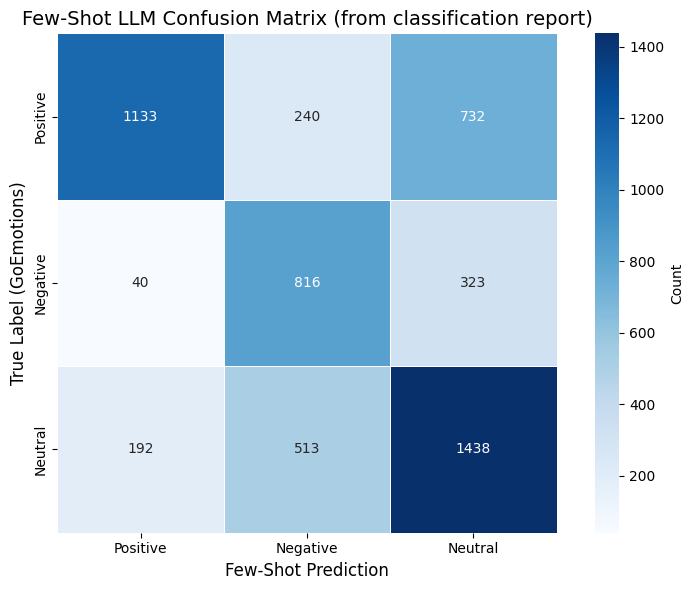

In [2]:
# Confusion matrix from classification report data (no inference needed)
# Data from: Few-Shot LLM Baseline Evaluation (3 Buckets)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels_order = ['Positive', 'Negative', 'Neutral']
precision = {'Positive': 0.83, 'Negative': 0.52, 'Neutral': 0.58}
recall    = {'Positive': 0.54, 'Negative': 0.69, 'Neutral': 0.67}
support   = {'Positive': 2098, 'Negative': 1182, 'Neutral': 2147}  # true row sums
n_total   = 5427

# True positives (diagonal) and predicted totals per class
tp = {k: round(recall[k] * support[k]) for k in labels_order}
pred_total = {k: round(tp[k] / precision[k]) for k in labels_order}

# Build 3x3 confusion matrix: rows = true, cols = predicted
# Diagonal = TP; fill off-diagonals so row sums = support, col sums = pred_total
cm = np.zeros((3, 3), dtype=float)
for i in range(3):
    cm[i, i] = tp[labels_order[i]]

row_remain = [support[labels_order[i]] - cm[i, i] for i in range(3)]
col_remain = [pred_total[labels_order[j]] - cm[j, j] for j in range(3)]
# Proportional allocation for off-diagonals
for i in range(3):
    for j in range(3):
        if i != j:
            cm[i, j] = (row_remain[i] * col_remain[j]) / (sum(col_remain) + 1e-9)
# Iterative proportional fitting: keep diagonal fixed, scale only off-diagonals
for _ in range(20):
    for i in range(3):
        row_sum = cm[i, :].sum()
        target = support[labels_order[i]]
        if row_sum > 1e-9 and abs(row_sum - target) > 0.5:
            scale = (target - cm[i, i]) / (row_sum - cm[i, i] + 1e-9)
            for j in range(3):
                if i != j:
                    cm[i, j] *= scale
    for j in range(3):
        col_sum = cm[:, j].sum()
        target = pred_total[labels_order[j]]
        if col_sum > 1e-9 and abs(col_sum - target) > 0.5:
            scale = (target - cm[j, j]) / (col_sum - cm[j, j] + 1e-9)
            for i in range(3):
                if i != j:
                    cm[i, j] *= scale
cm = np.round(cm).astype(int)
cm = np.maximum(cm, 0)
# Fix total to 5427 (rounding can leave small diff)
diff = n_total - cm.sum()
if diff != 0:
    # Add diff to largest off-diagonal to keep matrix valid
    off_diag = [(i, j) for i in range(3) for j in range(3) if i != j]
    idx = np.argmax([cm[i, j] for i, j in off_diag])
    i, j = off_diag[idx]
    cm[i, j] += diff

print("Reconstructed confusion matrix (from precision/recall/support):")
print("Rows = True label, Cols = Predicted")
print(cm)
print("Row sums:", cm.sum(axis=1), " Col sums:", cm.sum(axis=0), " Total:", cm.sum())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_order, yticklabels=labels_order,
            cbar_kws={'label': 'Count'}, square=True, linewidths=0.5)
plt.xlabel('Few-Shot Prediction', fontsize=12)
plt.ylabel('True Label (GoEmotions)', fontsize=12)
plt.title('Few-Shot LLM Confusion Matrix (from classification report)', fontsize=14)
plt.tight_layout()
plt.show()